# ⚙️ Chapter 8: Online DPO & Iterative Alignment

![Part](https://img.shields.io/badge/Part%20II-Core%20Methods-1F9D6B?style=for-the-badge) &nbsp; ![Tested](https://img.shields.io/badge/Tested-Colab%20T4-2FAE7E?style=for-the-badge) &nbsp; [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/Reinforcement-Learning-for-LLMs/blob/main/notebooks/part2_core/08_online_dpo.ipynb)

> 📘 **Book:** *Reinforcement Learning for Large Language Models*, Arun Shankar & Michael Chertushkin (Packt, 2026)  
> 📓 **Notebook:** `part2_core/08_online_dpo.ipynb`  
> ✅ **Tested on:** Google Colab (T4), 2026-06-29

> 📌 **What this notebook covers**  
> This is the companion notebook for Chapter 8 of the book. Run it on a free Colab T4 GPU. All code uses small, publicly available models (under 500 MB) that fit within the free-tier memory limit.

---

In [1]:
# === Setup: Chapter 8 · tested on Google Colab (T4), 2026-06-29 ===
# Self-contained: installs ONLY what this notebook imports (pinned).
# Versions are managed centrally in code/requirements.txt.
import os, sys
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")  # quiet HF download bars (keeps GitHub able to render the saved notebook)
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")  # reduce CUDA fragmentation on the T4
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q --progress-bar off transformers==5.5.0 bitsandbytes==0.49.2

import importlib
for _p in ["numpy", "torch", "transformers", "bitsandbytes"]:
    try:
        print(f"{_p:<16}", importlib.import_module(_p).__version__)
    except Exception as _e:
        print(f"{_p:<16} (not importable here)")


numpy            2.0.2
torch            2.11.0+cu128
transformers     5.5.0
bitsandbytes     0.49.2


In [2]:
import warnings
import random
import copy
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU : Tesla T4
VRAM: 15.6 GB


## Part 1: DPO Loss from Scratch

Before building the online loop we implement the DPO loss in pure PyTorch so the maths is transparent.

### What the formula says

DPO works by implicitly treating the log-ratio

$$\hat{r}_\theta(x, y) = \beta\log\frac{\pi_\theta(y|x)}{\pi_{\text{ref}}(y|x)}$$

as a reward. It then pushes $\hat{r}(y_w) - \hat{r}(y_l)$ to be as large and positive as possible, which is exactly what the Bradley-Terry model says the reward should do.

> 🧭 **New to this?** The *reference model* $\pi_{\text{ref}}$ is a **frozen copy of where we started**; $\beta$ controls **how far we're allowed to move** from it. A bigger $\beta$ is a shorter leash. No separate reward model is trained, the policy-vs-reference log-ratio *is* the implicit reward.

### The 20-line implementation


In [3]:
def sequence_log_prob(
    model: torch.nn.Module,
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor,
    response_start: int,
) -> torch.Tensor:
    """Sum of log-probabilities over the RESPONSE tokens only (prompt + padding masked)."""
    # NOTE: compute logits WITH grad. The policy needs gradients; dpo_loss wraps the
    # *reference* calls in torch.no_grad() separately. (Wrapping here broke loss.backward().)
    logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
    log_probs = F.log_softmax(logits[:, :-1, :], dim=-1)          # (1, T-1, V)
    target_ids = input_ids[:, 1:]                                  # (1, T-1)
    token_log_p = log_probs.gather(2, target_ids.unsqueeze(-1)).squeeze(-1)  # (1, T-1)
    resp_mask = torch.zeros_like(token_log_p)
    resp_mask[:, response_start - 1:] = 1.0                        # response region (after the shift)
    resp_mask = resp_mask * attention_mask[:, 1:].float()         # drop padding positions
    return (token_log_p * resp_mask).sum(dim=1)                    # (1,)


def dpo_loss(
    policy_model, ref_model,
    chosen_ids, chosen_mask, rejected_ids, rejected_mask,
    response_start_chosen, response_start_rejected, beta: float = 0.1,
):
    """DPO loss: -log sigmoid( beta * [ (pi_w - ref_w) - (pi_l - ref_l) ] )."""
    pi_logp_w = sequence_log_prob(policy_model, chosen_ids,   chosen_mask,   response_start_chosen)
    pi_logp_l = sequence_log_prob(policy_model, rejected_ids, rejected_mask, response_start_rejected)
    with torch.no_grad():
        ref_logp_w = sequence_log_prob(ref_model, chosen_ids,   chosen_mask,   response_start_chosen)
        ref_logp_l = sequence_log_prob(ref_model, rejected_ids, rejected_mask, response_start_rejected)
    margin = beta * ((pi_logp_w - ref_logp_w) - (pi_logp_l - ref_logp_l))
    return -F.logsigmoid(margin).mean()


print('DPO loss function defined.')

DPO loss function defined.


In [4]:
# Quick smoke-test: the loss should decrease as the margin grows
import torch.optim as optim

toy_model = AutoModelForCausalLM.from_pretrained('Qwen/Qwen2.5-0.5B').to(DEVICE)
toy_ref   = copy.deepcopy(toy_model); toy_ref.eval()
for p in toy_ref.parameters(): p.requires_grad = False

tok = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-0.5B')
tok.pad_token = tok.eos_token

prompt   = "The movie was "
chosen   = prompt + "wonderful and deeply moving."
rejected = prompt + "boring and a complete waste of time."

enc_c = tok(chosen,   return_tensors='pt', padding='max_length', max_length=32, truncation=True)
enc_r = tok(rejected, return_tensors='pt', padding='max_length', max_length=32, truncation=True)
prompt_len = len(tok.encode(prompt))
enc_c = {k: v.to(DEVICE) for k, v in enc_c.items()}
enc_r = {k: v.to(DEVICE) for k, v in enc_r.items()}

opt = optim.AdamW(toy_model.parameters(), lr=2e-6)  # DPO range; 5e-5 collapsed the loss in 1 step
print('Smoke test - 5 DPO steps:')
for s in range(5):
    toy_model.train()
    loss = dpo_loss(toy_model, toy_ref,
                    enc_c['input_ids'], enc_c['attention_mask'],
                    enc_r['input_ids'], enc_r['attention_mask'],
                    prompt_len, prompt_len)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(toy_model.parameters(), 1.0); opt.step()
    print(f'  step {s+1}  loss={loss.item():.4f}')

del toy_model, toy_ref, opt
import gc; gc.collect(); torch.cuda.empty_cache()

Smoke test - 5 DPO steps:
  step 1  loss=0.6931
  step 2  loss=0.6631
  step 3  loss=0.6324
  step 4  loss=0.6012
  step 5  loss=0.5647


## Part 2: Static DPO on a Fixed Dataset (Baseline)

Before implementing Online DPO we train a **static DPO** baseline on a fixed preference dataset. This is the vanilla DPO setting from Chapter 7, training data is never refreshed.

We will use this as the comparison point for the online variant.


In [5]:
from transformers import AutoModelForSequenceClassification

MODEL_NAME = 'Qwen/Qwen2.5-0.5B'   # base model -> continues review prefixes naturally

# --- Robust reward: a pretrained sentiment classifier (same one Chapter 6's PPO demo used) ---
SENT_MODEL = 'lvwerra/distilbert-imdb'
clf_tokenizer = AutoTokenizer.from_pretrained(SENT_MODEL)
clf_model = AutoModelForSequenceClassification.from_pretrained(SENT_MODEL).to(DEVICE).eval()
for prm in clf_model.parameters(): prm.requires_grad_(False)
POS_IDX = next((int(i) for i, l in clf_model.config.id2label.items() if 'POS' in str(l).upper()), 1)

@torch.no_grad()
def positivity(text):
    """Bounded reward in [0,1]: P(text is POSITIVE) under the pretrained classifier."""
    enc = clf_tokenizer(text, return_tensors='pt', truncation=True, max_length=128).to(DEVICE)
    return float(torch.softmax(clf_model(**enc).logits, dim=-1)[0, POS_IDX])

print('Reward sanity:  positive ->', round(positivity('a wonderful, heartfelt film'), 3),
      '| negative ->', round(positivity('a boring, awful film'), 3))

# Movie-review prefixes the model will continue.
REVIEW_PREFIXES = [
    "I watched this film and", "The movie was", "Honestly, this show",
    "The acting in this film", "I went to see it and", "This series",
    "The plot of this movie", "After watching the finale,", "The director's latest",
    "My friends and I saw", "The first episode", "This documentary",
    "The sequel", "Watching this again,", "The ending",
]

# Static (offline) preference pairs: same prefix, a positive vs a negative continuation.
STATIC_PAIRS = [
    {"prompt": "I watched this film and",   "chosen": "loved every minute - wonderful, moving, and beautifully made.", "rejected": "regretted it; dull, lifeless, and a complete waste of time."},
    {"prompt": "The movie was",             "chosen": "fantastic - heartfelt, gripping, and genuinely uplifting.",     "rejected": "terrible - boring, poorly acted, and painfully slow."},
    {"prompt": "Honestly, this show",       "chosen": "is brilliant; charming characters and sharp, witty writing.",   "rejected": "is awful; flat characters and lazy, tedious writing."},
    {"prompt": "The acting in this film",   "chosen": "was superb - every performance felt real and deeply touching.", "rejected": "was dreadful - wooden, unconvincing, and hard to watch."},
    {"prompt": "I went to see it and",      "chosen": "had a wonderful time; funny, warm, and a joy throughout.",      "rejected": "wished I hadn't; a tedious, forgettable mess."},
    {"prompt": "This series",               "chosen": "is excellent - smart, exciting, and impossible to stop watching.","rejected": "is bad - tedious, predictable, and a chore to finish."},
    {"prompt": "The plot of this movie",    "chosen": "was clever and gripping, with a satisfying, emotional payoff.", "rejected": "was a confusing, boring slog with no real point."},
    {"prompt": "After watching the finale,","chosen": "I was moved to tears - a beautiful, perfect ending.",           "rejected": "I felt cheated - a dull, disappointing letdown."},
    {"prompt": "The director's latest",     "chosen": "is a masterpiece - visually stunning and emotionally rich.",    "rejected": "is a misfire - flat, joyless, and instantly forgettable."},
    {"prompt": "My friends and I saw",      "chosen": "it and adored it; we laughed, we cried, we loved it.",          "rejected": "it and hated it; we were bored and left disappointed."},
]
print(f'{len(REVIEW_PREFIXES)} prefixes | {len(STATIC_PAIRS)} static preference pairs')

Reward sanity:  positive -> 0.996 | negative -> 0.003
15 prefixes | 10 static preference pairs


In [6]:
static_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
static_tokenizer.pad_token = static_tokenizer.eos_token
static_tokenizer.padding_side = 'right'

static_policy  = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
static_ref     = copy.deepcopy(static_policy)
static_ref.eval()
for p in static_ref.parameters():
    p.requires_grad = False


def encode_pair(prompt_text, response_text, tokenizer, max_len=64):
    """Encode prefix + continuation as one sequence; response_start = end of the prefix."""
    full = prompt_text + " " + response_text
    enc  = tokenizer(full, return_tensors='pt',
                     padding='max_length', max_length=max_len, truncation=True)
    prefix_len = len(tokenizer.encode(prompt_text))
    return enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE), prefix_len


import bitsandbytes as bnb
static_opt  = bnb.optim.AdamW8bit(static_policy.parameters(), lr=1e-6)  # DPO-appropriate LR (8-bit Adam, T4)
STATIC_EPOCHS = 4
static_loss_log = []

print('Training static DPO ...')
for epoch in range(STATIC_EPOCHS):
    random.shuffle(STATIC_PAIRS)
    epoch_losses = []
    static_policy.train()
    for pair in STATIC_PAIRS:
        ids_w, mask_w, rs_w = encode_pair(pair['prompt'], pair['chosen'],   static_tokenizer)
        ids_l, mask_l, rs_l = encode_pair(pair['prompt'], pair['rejected'], static_tokenizer)
        loss = dpo_loss(static_policy, static_ref, ids_w, mask_w, ids_l, mask_l, rs_w, rs_l, beta=0.1)
        static_opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(static_policy.parameters(), 1.0); static_opt.step()
        epoch_losses.append(loss.item())
    avg = float(np.mean(epoch_losses)); static_loss_log.append(avg)
    print(f'  Epoch {epoch+1}/{STATIC_EPOCHS}  loss={avg:.4f}')

print('Static DPO complete.')
import gc; del static_opt; gc.collect(); torch.cuda.empty_cache()  # free Adam state before Part 3

Training static DPO ...
  Epoch 1/4  loss=0.6964
  Epoch 2/4  loss=0.6804
  Epoch 3/4  loss=0.6747
  Epoch 4/4  loss=0.6711
Static DPO complete.


## Part 3: Online DPO: Self-Generated Preferences

The key idea in Online DPO:

1. **Generate** two responses per prompt using temperature sampling (diversity).
2. **Score** both responses with a **sentiment classifier**, a fast, robust preference signal.
3. **Assign** `chosen = higher score`, `rejected = lower score`.
4. **Compute** DPO loss on this freshly generated pair.
5. **Update** the policy weights.
6. **Repeat**: each iteration the data comes from the *current* policy.

### Why does this help?
Static DPO trains on data collected from a *historical* model. As the policy improves the static data becomes stale, and the policy keeps trying to contrast responses it no longer produces. Online DPO avoids this by keeping the training distribution on-policy at all times.


In [7]:
ONLINE_PROMPTS = REVIEW_PREFIXES   # continue review prefixes; prefer the more positive sample
print(f'Online DPO prompt pool: {len(ONLINE_PROMPTS)} review prefixes')

Online DPO prompt pool: 15 review prefixes


In [8]:
# The reward is the pretrained sentiment classifier defined above (positivity).
print('Positivity reward on sample continuations:')
for ex in ["a wonderful, heartfelt film", "an okay way to spend an evening", "a boring, lifeless mess"]:
    print(f'  {positivity(ex):.3f}  "{ex}"')

Positivity reward on sample continuations:
  0.996  "a wonderful, heartfelt film"
  0.816  "an okay way to spend an evening"
  0.003  "a boring, lifeless mess"


> ✅ **A robust reward.** Instead of a hand-written proxy that just counts length and keywords (easy to game), we score each self-generated continuation with a **pretrained sentiment classifier** (the same one Chapter 6 used). Its output is a bounded probability that the text is *positive*, so the policy can't cheat by padding length, it has to genuinely become more positive. Online DPO then prefers the more positive of the two sampled continuations.

In [9]:
def generate_two_responses(model, tokenizer, prompt: str,
                           max_new_tokens: int = 40, device: str = 'cpu'):
    """Sample two independent continuations of the prefix. Returns (resp_a, resp_b)."""
    enc = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=64)
    enc = {k: v.to(device) for k, v in enc.items()}
    prompt_len = enc['input_ids'].shape[1]
    model.eval()
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=True,
                             temperature=0.9, top_k=50, num_return_sequences=2,
                             repetition_penalty=1.3, no_repeat_ngram_size=3,
                             pad_token_id=tokenizer.eos_token_id)
    a = tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True).strip()
    b = tokenizer.decode(out[1][prompt_len:], skip_special_tokens=True).strip()
    return a, b

print('generate_two_responses defined.')

generate_two_responses defined.


In [10]:
online_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
online_tokenizer.pad_token = online_tokenizer.eos_token
online_tokenizer.padding_side = 'right'

online_policy = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
online_ref    = copy.deepcopy(online_policy); online_ref.eval()
for p in online_ref.parameters():
    p.requires_grad = False

import bitsandbytes as bnb
online_opt = bnb.optim.AdamW8bit(online_policy.parameters(), lr=1e-6)  # DPO-appropriate LR (8-bit Adam, T4)

ONLINE_STEPS     = 50
online_loss_log  = []
online_score_log = []

print(f'Running Online DPO for {ONLINE_STEPS} steps ...')
for step in range(ONLINE_STEPS):
    prompt = random.choice(ONLINE_PROMPTS)
    # 1. generate two continuations from the current policy
    resp_a, resp_b = generate_two_responses(online_policy, online_tokenizer, prompt, device=DEVICE)
    # 2. score each with the robust sentiment reward
    score_a = positivity(prompt + " " + resp_a)
    score_b = positivity(prompt + " " + resp_b)
    # 3. chosen = the more positive continuation
    if score_a >= score_b:
        chosen_resp, rejected_resp, score_chosen = resp_a, resp_b, score_a
    else:
        chosen_resp, rejected_resp, score_chosen = resp_b, resp_a, score_b
    online_score_log.append(score_chosen)
    # 4. DPO loss on the self-generated pair
    ids_w, mask_w, rs_w = encode_pair(prompt, chosen_resp,   online_tokenizer)
    ids_l, mask_l, rs_l = encode_pair(prompt, rejected_resp, online_tokenizer)
    online_policy.train()
    loss = dpo_loss(online_policy, online_ref, ids_w, mask_w, ids_l, mask_l, rs_w, rs_l, beta=0.1)
    # 5. update
    online_opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(online_policy.parameters(), 1.0); online_opt.step()
    online_loss_log.append(loss.item())
    if (step + 1) % 10 == 0:
        print(f'Step {step+1:3d}/{ONLINE_STEPS}  loss={loss.item():.4f}  positivity_chosen={score_chosen:.3f}')

print('Online DPO training complete!')
import gc; del online_opt; gc.collect(); torch.cuda.empty_cache()  # free Adam state; Part 6 needs all 4 models

Running Online DPO for 50 steps ...
Step  10/50  loss=0.7546  positivity_chosen=0.952
Step  20/50  loss=0.7224  positivity_chosen=0.924
Step  30/50  loss=0.6721  positivity_chosen=0.789
Step  40/50  loss=0.6826  positivity_chosen=0.687
Step  50/50  loss=0.6973  positivity_chosen=0.952
Online DPO training complete!


## Part 4: Visualising Online DPO Training


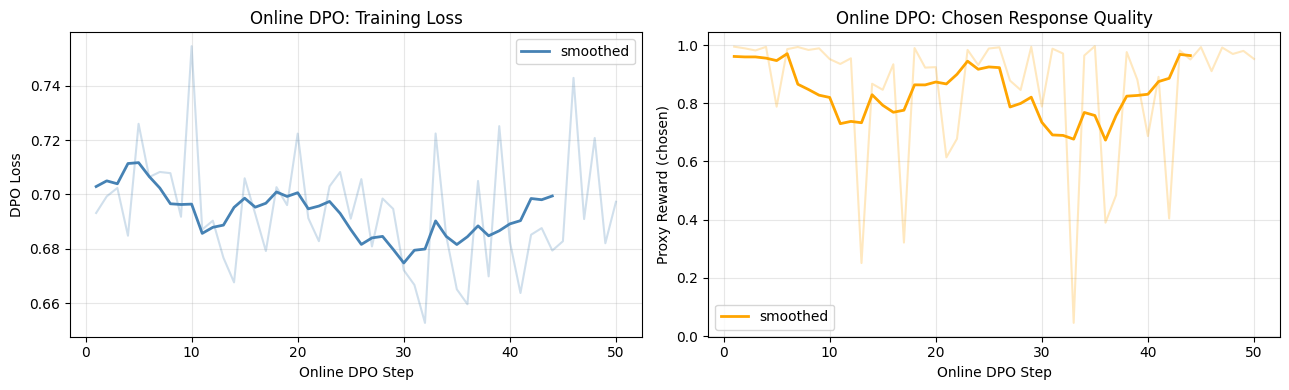

In [11]:
def smooth(data, w=7):
    if len(data) < w:
        return np.array(data)
    return np.convolve(data, np.ones(w) / w, mode='valid')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

steps = np.arange(1, ONLINE_STEPS + 1)

# Loss
ax1.plot(steps, online_loss_log, alpha=0.25, color='steelblue')
sl = smooth(online_loss_log)
ax1.plot(np.arange(1, len(sl) + 1), sl, color='steelblue', linewidth=2, label='smoothed')
ax1.set_xlabel('Online DPO Step')
ax1.set_ylabel('DPO Loss')
ax1.set_title('Online DPO: Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Proxy score of chosen response
ax2.plot(steps, online_score_log, alpha=0.25, color='orange')
ss = smooth(online_score_log)
ax2.plot(np.arange(1, len(ss) + 1), ss, color='orange', linewidth=2, label='smoothed')
ax2.set_xlabel('Online DPO Step')
ax2.set_ylabel('Proxy Reward (chosen)')
ax2.set_title('Online DPO: Chosen Response Quality')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('online_dpo_training.png', dpi=100, bbox_inches='tight')
plt.show()

## Part 5: Static DPO vs. Online DPO Evaluation

We evaluate both policies on **held-out review prefixes**. For each, the model greedily continues the prefix and we score the continuation with the **sentiment classifier**. Higher average positivity = the policy learned to write more positive continuations.

In [12]:
EVAL_PROMPTS = [
    "I just finished watching", "The film", "This new release",
    "Overall, the show", "The cast", "By the end of the movie,",
]

def eval_policy(model, tokenizer, prompts, device, max_new_tokens=40):
    """Continue each prefix (greedy) and return the sentiment positivity of each continuation."""
    scores = []
    model.eval()
    for pr in prompts:
        enc = tokenizer(pr, return_tensors='pt', truncation=True, max_length=64)
        enc = {k: v.to(device) for k, v in enc.items()}
        plen = enc['input_ids'].shape[1]
        with torch.no_grad():
            out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                                 repetition_penalty=1.3, no_repeat_ngram_size=3,
                                 pad_token_id=tokenizer.eos_token_id)
        resp = tokenizer.decode(out[0][plen:], skip_special_tokens=True).strip()
        scores.append(positivity(pr + " " + resp))
    return scores

static_scores = eval_policy(static_policy, static_tokenizer, EVAL_PROMPTS, DEVICE)
online_scores = eval_policy(online_policy, online_tokenizer, EVAL_PROMPTS, DEVICE)
print(f'Static DPO  avg positivity: {np.mean(static_scores):.4f}')
print(f'Online DPO  avg positivity: {np.mean(online_scores):.4f}')

Static DPO  avg positivity: 0.8309
Online DPO  avg positivity: 0.8739


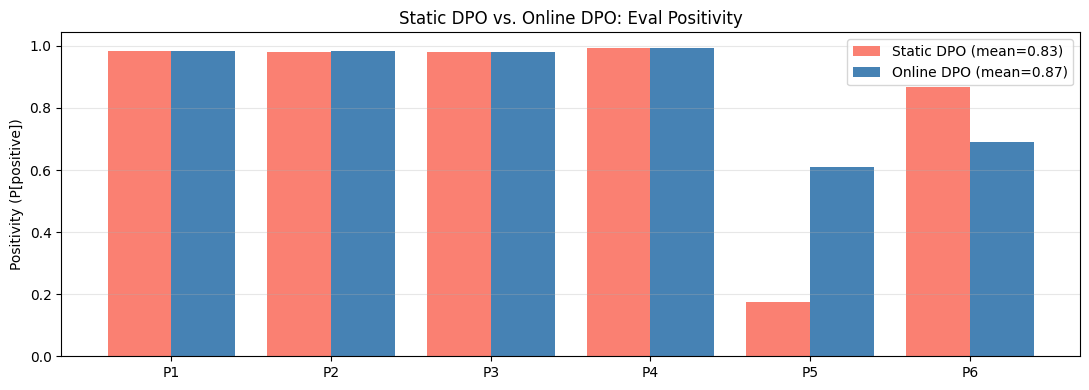

In [13]:
x = np.arange(len(EVAL_PROMPTS))
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - 0.2, static_scores, 0.4, label=f'Static DPO (mean={np.mean(static_scores):.2f})', color='salmon')
ax.bar(x + 0.2, online_scores, 0.4, label=f'Online DPO (mean={np.mean(online_scores):.2f})', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels([f'P{i+1}' for i in range(len(EVAL_PROMPTS))])
ax.set_ylabel('Positivity (P[positive])')
ax.set_title('Static DPO vs. Online DPO: Eval Positivity')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('static_vs_online_dpo.png', dpi=100, bbox_inches='tight')
plt.show()

In [14]:
# Head-to-head wins
online_wins  = sum(o > s for o, s in zip(online_scores, static_scores))
static_wins  = sum(s > o for o, s in zip(online_scores, static_scores))
ties         = len(EVAL_PROMPTS) - online_wins - static_wins
print('Head-to-head on eval prompts:')
print(f'  Online DPO wins : {online_wins}/{len(EVAL_PROMPTS)}')
print(f'  Static DPO wins : {static_wins}/{len(EVAL_PROMPTS)}')
print(f'  Ties            : {ties}/{len(EVAL_PROMPTS)}')

Head-to-head on eval prompts:
  Online DPO wins : 2/6
  Static DPO wins : 1/6
  Ties            : 3/6


## Part 6: Visualising DPO Implicit Reward Margins

One helpful diagnostic is to plot the **implicit reward margin**, the difference in log-ratios between chosen and rejected. A well-trained DPO policy should have a consistently positive margin.

> 📊 **Reading this honestly:** the *online* policy is scored here on the **static** evaluation pairs it never trained on, so its margins can look modest or even slightly negative. That's expected, it was optimized against its *own* generations, not these fixed pairs, not a bug in the code.


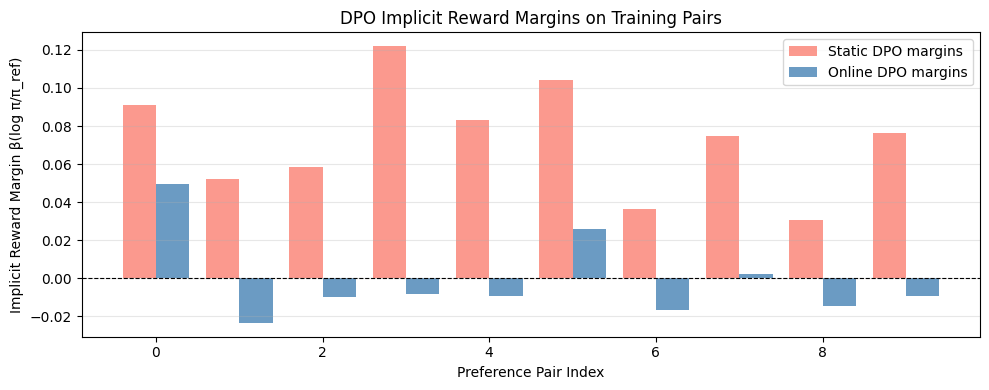

Static DPO mean margin: +0.0729
Online DPO mean margin: -0.0014


In [15]:
def compute_margin(policy, ref, tokenizer, pairs, device, beta=0.1):
    """Compute implicit reward margin for a list of preference pairs."""
    margins = []
    policy.eval()
    for pair in pairs:
        ids_w, mask_w, rs_w = encode_pair(pair['prompt'], pair['chosen'],   tokenizer)
        ids_l, mask_l, rs_l = encode_pair(pair['prompt'], pair['rejected'], tokenizer)
        with torch.no_grad():
            pi_w  = sequence_log_prob(policy, ids_w, mask_w, rs_w)
            pi_l  = sequence_log_prob(policy, ids_l, mask_l, rs_l)
            ref_w = sequence_log_prob(ref,    ids_w, mask_w, rs_w)
            ref_l = sequence_log_prob(ref,    ids_l, mask_l, rs_l)
        margin = float(beta * ((pi_w - ref_w) - (pi_l - ref_l)).item())
        margins.append(margin)
    return margins


static_margins = compute_margin(
    static_policy, static_ref, static_tokenizer, STATIC_PAIRS, DEVICE
)
online_margins = compute_margin(
    online_policy, online_ref, online_tokenizer, STATIC_PAIRS, DEVICE
)

fig, ax = plt.subplots(figsize=(10, 4))
xi = np.arange(len(STATIC_PAIRS))
ax.bar(xi - 0.2, static_margins, 0.4, label='Static DPO margins', color='salmon', alpha=0.8)
ax.bar(xi + 0.2, online_margins, 0.4, label='Online DPO margins', color='steelblue', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Preference Pair Index')
ax.set_ylabel('Implicit Reward Margin β(log π/π_ref)')
ax.set_title('DPO Implicit Reward Margins on Training Pairs')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('dpo_margins.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Static DPO mean margin: {np.mean(static_margins):+.4f}')
print(f'Online DPO mean margin: {np.mean(online_margins):+.4f}')

## Summary: Online DPO vs. Static DPO

| Aspect | Static DPO | Online DPO |
|--------|-----------|------------|
| Data source | Fixed dataset collected once | Model's own samples at each step |
| Distribution | Shifts away from current policy over time | Always on-policy |
| Preference source | Fixed, pre-labelled pairs | A judge/classifier labels each fresh self-generated pair |
| Compute | One pass through dataset | Inference cost at each step |
| Risk | Off-policy degradation | Reward hacking if proxy is weak |

### Key takeaways
- Online DPO keeps training data on-policy, addressing the **distribution shift** problem of static DPO. At this **toy scale** (0.5B model, a noisy proxy reward, ~50 steps) online does not *always* beat static on a given run, the mechanism is the lesson, not a guaranteed win.
- **Scope note:** Chapter 8 also covers **STaR** and **Expert Iteration** conceptually; this notebook focuses on the **Online DPO loop** specifically. STaR/Expert-Iteration are left as chapter reading.
- The reward/judge that labels online pairs must be reliable, a weak or gameable one leads to reward hacking (Chapter 9).
- Iterative / online variants generalise: the same loop works with real human labels or a learned RM.

> **Next chapter** → Chapter 9 dives into reward model architecture, calibration, and the adversarial failure modes (reward hacking) that the online setting is designed to mitigate.


In [16]:
print('=== Online DPO: Training Summary ===')
print(f'Static DPO preference pairs : {len(STATIC_PAIRS)}')
print(f'Online DPO steps            : {ONLINE_STEPS}')
print(f'Online DPO prompts pool     : {len(ONLINE_PROMPTS)}')
print(f'Eval prompts                : {len(EVAL_PROMPTS)}')
print(f'Static DPO avg eval positivity   : {np.mean(static_scores):.4f}')
print(f'Online DPO avg eval positivity   : {np.mean(online_scores):.4f}')
delta = np.mean(online_scores) - np.mean(static_scores)
print(f'Online improvement          : {"+" if delta >= 0 else ""}{delta:.4f}')
print(f'Static DPO mean margin      : {np.mean(static_margins):+.4f}')
print(f'Online DPO mean margin      : {np.mean(online_margins):+.4f}')

=== Online DPO: Training Summary ===
Static DPO preference pairs : 10
Online DPO steps            : 50
Online DPO prompts pool     : 15
Eval prompts                : 6
Static DPO avg eval positivity   : 0.8309
Online DPO avg eval positivity   : 0.8739
Online improvement          : +0.0430
Static DPO mean margin      : +0.0729
Online DPO mean margin      : -0.0014
